# Lap Time Telemetry Analysis

This notebook reads the telemetry CSV selected by `CSV_PATH`, derives one summary row per timed lap, and visualizes lap times, sector performance, speed traces, and the fastest lap around the GPS track.

`Lap == 0` is treated as untimed session data because its elapsed-time value remains zero. For timed laps, the final recorded `Elapsed Time (ms)` value is used as the lap time.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 50)

## Load and validate the telemetry

In [2]:
# Change these two settings to select a session and sector granularity.
CSV_PATH = Path("data/telemetry-v1-2026-07-14-19_28_47.csv")
N_SECTORS = 3

if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Telemetry CSV not found: {CSV_PATH.resolve()}")
if not isinstance(N_SECTORS, int) or N_SECTORS < 1:
    raise ValueError("N_SECTORS must be a positive integer")

telemetry = pd.read_csv(CSV_PATH).assign(Source=CSV_PATH.name)

required_columns = {
    "Lap", "Elapsed Time (ms)", "Speed (MPH)",
    "Latitude (decimal)", "Longitude (decimal)",
    "Throttle Position (%)", "Brake Pressure (bar)",
}
missing_columns = required_columns.difference(telemetry.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

numeric_columns = telemetry.columns.difference(["Source"])
telemetry[numeric_columns] = telemetry[numeric_columns].apply(pd.to_numeric, errors="coerce")

print(f"Loaded {len(telemetry):,} samples from {CSV_PATH}")
print(f"Columns: {len(telemetry.columns) - 1} telemetry channels")

Loaded 46,705 samples from data\telemetry-v1-2026-07-14-19_28_47.csv
Columns: 29 telemetry channels


In [3]:
quality_summary = pd.DataFrame(
    {
        "Metric": ["Rows", "Exact duplicate rows", "Missing values", "Observed lap IDs"],
        "Value": [
            f"{len(telemetry):,}",
            f"{telemetry.drop(columns='Source').duplicated().sum():,}",
            f"{telemetry.isna().sum().sum():,}",
            ", ".join(map(str, sorted(telemetry["Lap"].dropna().astype(int).unique()))),
        ],
    }
)
display(quality_summary.style.hide(axis="index"))

Metric,Value
Rows,"46,705"
Exact duplicate rows,"9,425"
Missing values,0
Observed lap IDs,"0, 1, 2, 3, 4"


## Lap-time summary

Only positive lap IDs with positive elapsed time are included below. Exact duplicate rows are reported above but retained; the timed laps have one distinct elapsed timestamp per sample.

In [4]:
timed = telemetry.loc[
    telemetry["Lap"].gt(0) & telemetry["Elapsed Time (ms)"].gt(0)
].copy()
timed["Lap"] = timed["Lap"].astype(int)
timed = timed.sort_values(["Lap", "Elapsed Time (ms)"])
timed["Elapsed (s)"] = timed["Elapsed Time (ms)"] / 1_000

def format_lap_time(milliseconds):
    total_ms = int(round(milliseconds))
    minutes, remainder = divmod(total_ms, 60_000)
    seconds, millis = divmod(remainder, 1_000)
    return f"{minutes}:{seconds:02d}.{millis:03d}"

lap_summary = (
    timed.groupby("Lap", as_index=False)
    .agg(
        **{
            "First Sample (ms)": ("Elapsed Time (ms)", "min"),
            "Lap Time (ms)": ("Elapsed Time (ms)", "max"),
            "Samples": ("Elapsed Time (ms)", "size"),
            "Average Speed (MPH)": ("Speed (MPH)", "mean"),
            "Maximum Speed (MPH)": ("Speed (MPH)", "max"),
            "Average Throttle (%)": ("Throttle Position (%)", "mean"),
            "Maximum Brake (bar)": ("Brake Pressure (bar)", "max"),
        }
    )
)
lap_summary["Lap Time (s)"] = lap_summary["Lap Time (ms)"] / 1_000
lap_summary["Lap Time"] = lap_summary["Lap Time (ms)"].map(format_lap_time)
lap_summary["Median Sample Interval (ms)"] = lap_summary["Lap"].map(
    timed.groupby("Lap")["Elapsed Time (ms)"].apply(lambda values: values.diff().median())
)

fastest_idx = lap_summary["Lap Time (ms)"].idxmin()
fastest_lap = int(lap_summary.loc[fastest_idx, "Lap"])
fastest_ms = int(lap_summary.loc[fastest_idx, "Lap Time (ms)"])
lap_summary["Gap to Fastest (s)"] = (lap_summary["Lap Time (ms)"] - fastest_ms) / 1_000

summary_columns = [
    "Lap", "Lap Time", "Gap to Fastest (s)", "Average Speed (MPH)",
    "Maximum Speed (MPH)", "Average Throttle (%)", "Maximum Brake (bar)",
    "Samples", "Median Sample Interval (ms)",
]
display(
    lap_summary[summary_columns]
    .style.hide(axis="index")
    .format(
        {
            "Gap to Fastest (s)": "{:+.3f}",
            "Average Speed (MPH)": "{:.1f}",
            "Maximum Speed (MPH)": "{:.1f}",
            "Average Throttle (%)": "{:.1f}",
            "Maximum Brake (bar)": "{:.1f}",
            "Median Sample Interval (ms)": "{:.0f}",
        }
    )
    .apply(
        lambda row: ["background-color: #d8f3dc; font-weight: bold"] * len(row)
        if row["Lap"] == fastest_lap else [""] * len(row),
        axis=1,
    )
)
print(f"Fastest recorded lap: Lap {fastest_lap} in {format_lap_time(fastest_ms)}")

Lap,Lap Time,Gap to Fastest (s),Average Speed (MPH),Maximum Speed (MPH),Average Throttle (%),Maximum Brake (bar),Samples,Median Sample Interval (ms)
1,2:09.496,+11.894,67.1,131.1,41.1,45.9,6472,17
2,1:57.602,+0.000,74.3,136.7,46.0,72.3,5880,17
3,2:14.384,+16.782,64.8,136.1,37.5,82.8,6718,17
4,3:07.034,+69.432,49.6,136.1,31.3,66.6,9351,17


Fastest recorded lap: Lap 2 in 1:57.602


## Sector analysis and theoretical fastest lap

Each lap is split into `N_SECTORS` equal-distance sectors using its GPS trace. Sector-boundary times are interpolated between samples, and the theoretical fastest lap combines the quickest observed time in each sector.

In [5]:
EARTH_RADIUS_M = 6_371_000

def lap_sector_times(lap, lap_data, n_sectors):
    lap_data = (
        lap_data.dropna(
            subset=["Elapsed Time (ms)", "Latitude (decimal)", "Longitude (decimal)"]
        )
        .sort_values("Elapsed Time (ms)")
    )
    if len(lap_data) < 2:
        raise ValueError(f"Lap {lap} does not have enough GPS samples")

    latitude = np.radians(lap_data["Latitude (decimal)"].to_numpy(dtype=float))
    longitude = np.radians(lap_data["Longitude (decimal)"].to_numpy(dtype=float))
    d_latitude = np.diff(latitude)
    d_longitude = np.diff(longitude)
    haversine = (
        np.sin(d_latitude / 2) ** 2
        + np.cos(latitude[:-1]) * np.cos(latitude[1:]) * np.sin(d_longitude / 2) ** 2
    )
    step_distance = 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(np.clip(haversine, 0, 1)))
    cumulative_distance = np.concatenate(([0.0], np.cumsum(step_distance)))
    total_distance = cumulative_distance[-1]
    if not np.isfinite(total_distance) or total_distance <= 0:
        raise ValueError(f"Lap {lap} does not have a usable GPS trace")

    # Remove stationary duplicate points before interpolation. The final boundary is
    # explicitly set to the recorded lap time so all sectors sum to the full lap.
    moving = np.r_[True, np.diff(cumulative_distance) > 0]
    elapsed_ms = lap_data["Elapsed Time (ms)"].to_numpy(dtype=float)
    boundaries = np.linspace(0, total_distance, n_sectors + 1)
    boundary_times = np.interp(boundaries, cumulative_distance[moving], elapsed_ms[moving])
    boundary_times[0] = 0.0
    boundary_times[-1] = elapsed_ms[-1]
    return np.diff(boundary_times), total_distance

sector_records = []
for lap, lap_data in timed.groupby("Lap"):
    sector_times_ms, lap_distance_m = lap_sector_times(lap, lap_data, N_SECTORS)
    for sector, sector_time_ms in enumerate(sector_times_ms, start=1):
        sector_records.append(
            {
                "Lap": lap,
                "Sector": sector,
                "Sector Time (ms)": sector_time_ms,
                "GPS Lap Distance (m)": lap_distance_m,
            }
        )

sector_results = pd.DataFrame(sector_records)
sector_times = sector_results.pivot(index="Lap", columns="Sector", values="Sector Time (ms)")
sector_times.columns = [f"S{sector}" for sector in sector_times.columns]
sector_times["Sector Sum"] = sector_times.sum(axis=1)
sector_times = sector_times.reset_index()

display(
    sector_times.style.hide(axis="index").format(
        {column: lambda value: format_lap_time(value) for column in sector_times.columns if column != "Lap"}
    )
)

best_sector_indices = sector_results.groupby("Sector")["Sector Time (ms)"].idxmin()
best_sectors = sector_results.loc[best_sector_indices, ["Sector", "Lap", "Sector Time (ms)"]].copy()
best_sectors["Sector Time"] = best_sectors["Sector Time (ms)"].map(format_lap_time)
theoretical_fastest_ms = best_sectors["Sector Time (ms)"].sum()
theoretical_gain_ms = fastest_ms - theoretical_fastest_ms

display(best_sectors[["Sector", "Lap", "Sector Time"]].style.hide(axis="index"))
print(f"Theoretical fastest lap: {format_lap_time(theoretical_fastest_ms)}")
print(f"Potential gain over Lap {fastest_lap}: {theoretical_gain_ms / 1_000:.3f} s")

Lap,S1,S2,S3,Sector Sum
1,0:38.140,0:50.824,0:40.532,2:09.496
2,0:39.031,0:41.028,0:37.543,1:57.602
3,0:35.530,0:54.452,0:44.402,2:14.384
4,0:37.198,0:54.384,1:35.451,3:07.034


Sector,Lap,Sector Time
1,3,0:35.530
2,2,0:41.028
3,2,0:37.543


Theoretical fastest lap: 1:54.101
Potential gain over Lap 2: 3.501 s


## Lap-time comparison

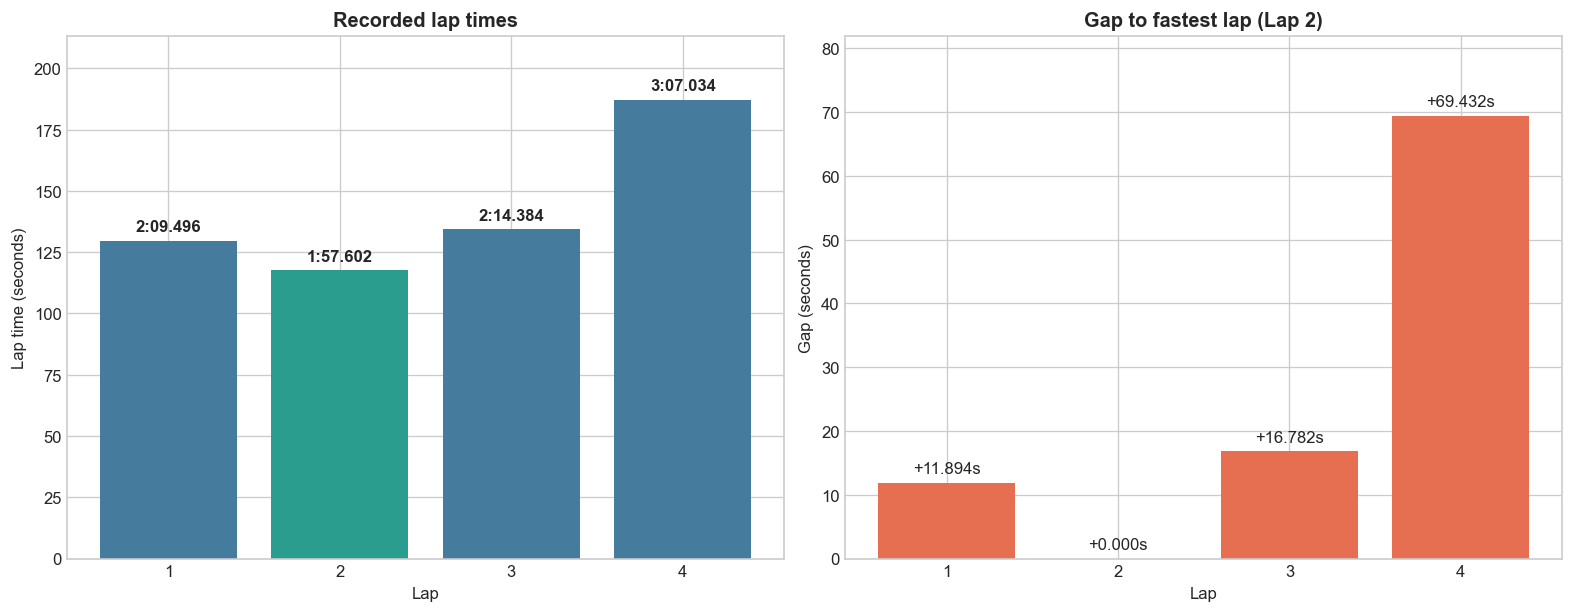

In [6]:
colors = ["#2a9d8f" if lap == fastest_lap else "#457b9d" for lap in lap_summary["Lap"]]
fig, (ax_time, ax_gap) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

bars = ax_time.bar(lap_summary["Lap"].astype(str), lap_summary["Lap Time (s)"], color=colors)
ax_time.bar_label(bars, labels=lap_summary["Lap Time"], padding=4, fontweight="bold")
ax_time.set(title="Recorded lap times", xlabel="Lap", ylabel="Lap time (seconds)")
ax_time.set_ylim(0, lap_summary["Lap Time (s)"].max() * 1.14)

gap_colors = ["#2a9d8f" if gap == 0 else "#e76f51" for gap in lap_summary["Gap to Fastest (s)"]]
gap_bars = ax_gap.bar(
    lap_summary["Lap"].astype(str), lap_summary["Gap to Fastest (s)"], color=gap_colors
)
ax_gap.bar_label(
    gap_bars, labels=[f"{gap:+.3f}s" for gap in lap_summary["Gap to Fastest (s)"]], padding=4
)
ax_gap.set(title=f"Gap to fastest lap (Lap {fastest_lap})", xlabel="Lap", ylabel="Gap (seconds)")
ax_gap.set_ylim(0, max(1, lap_summary["Gap to Fastest (s)"].max() * 1.18))
plt.show()

## Speed traces by lap

The trace makes it easier to see where time was gained or lost and whether a long lap contains low-speed running.

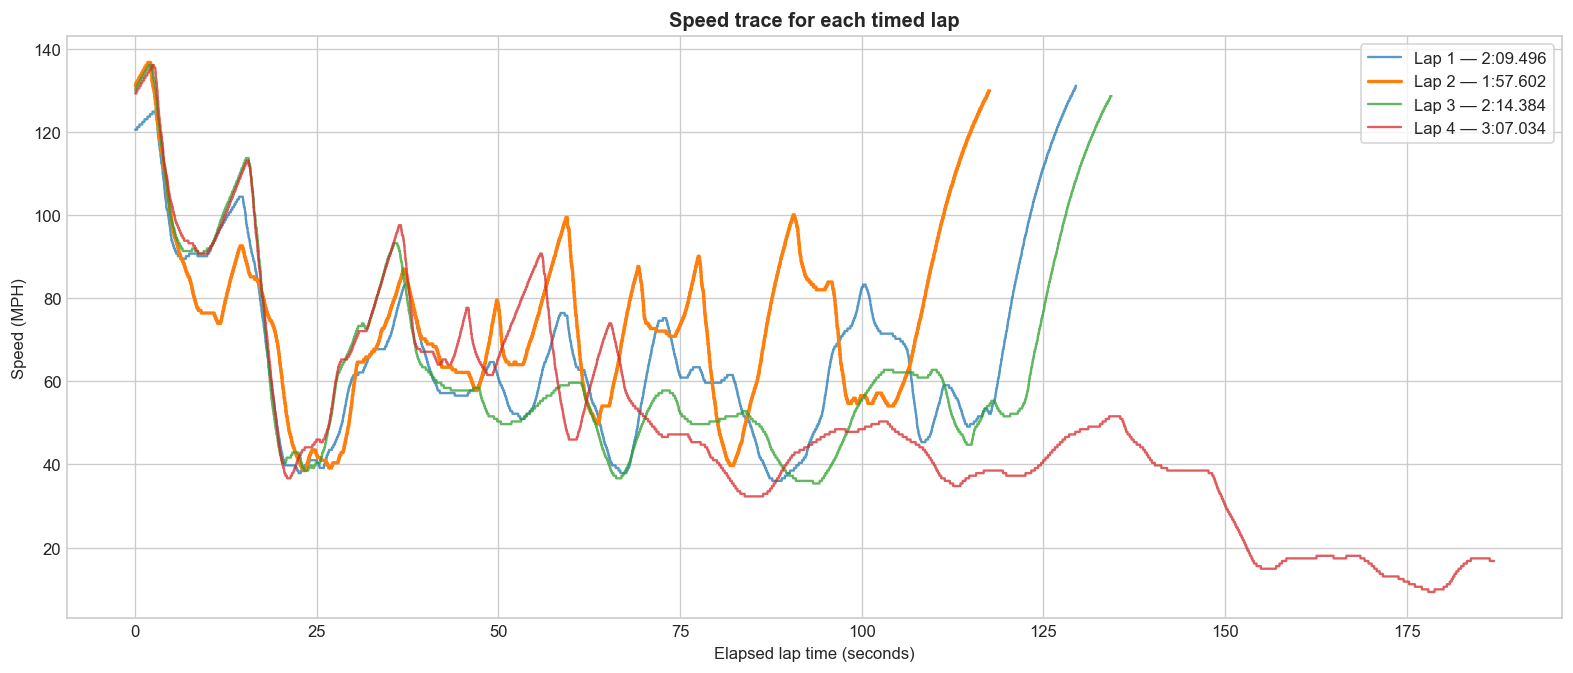

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
for lap, lap_data in timed.groupby("Lap"):
    lap_time = lap_summary.loc[lap_summary["Lap"].eq(lap), "Lap Time"].iloc[0]
    ax.plot(
        lap_data["Elapsed (s)"], lap_data["Speed (MPH)"],
        linewidth=2.0 if lap == fastest_lap else 1.4,
        alpha=1.0 if lap == fastest_lap else 0.75,
        label=f"Lap {lap} — {lap_time}",
    )
ax.set(
    title="Speed trace for each timed lap",
    xlabel="Elapsed lap time (seconds)",
    ylabel="Speed (MPH)",
)
ax.legend(frameon=True)
plt.show()

## Fastest-lap controls and track map

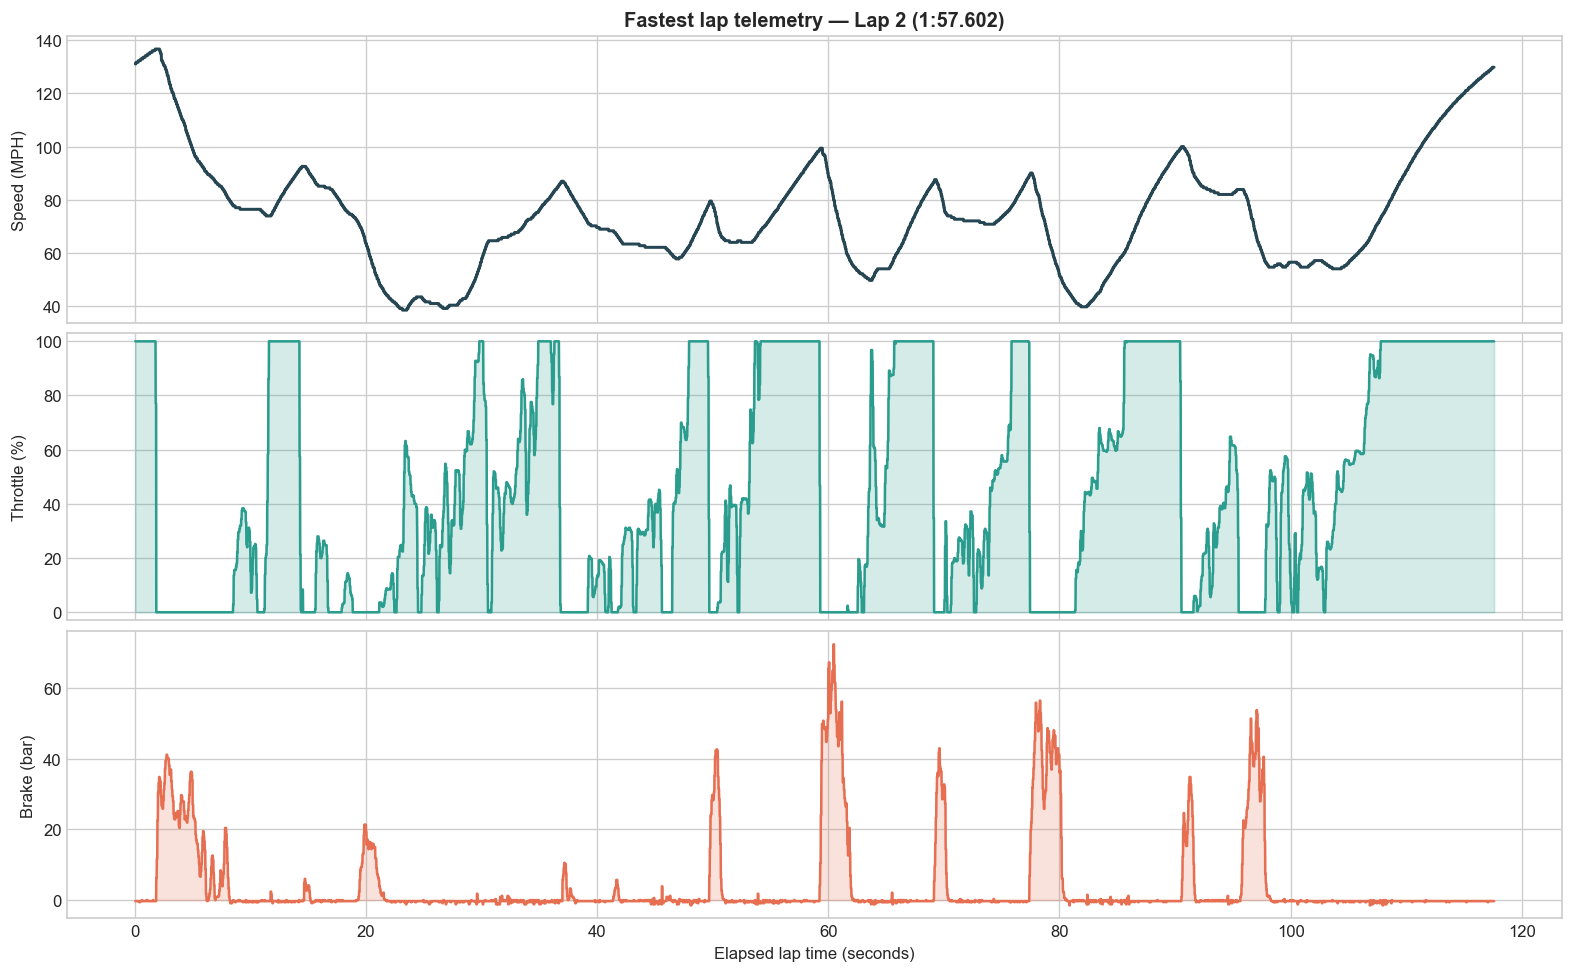

In [8]:
fastest = timed.loc[timed["Lap"].eq(fastest_lap)].copy()

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
axes[0].plot(fastest["Elapsed (s)"], fastest["Speed (MPH)"], color="#264653", linewidth=1.8)
axes[0].set_ylabel("Speed (MPH)")
axes[0].set_title(f"Fastest lap telemetry — Lap {fastest_lap} ({format_lap_time(fastest_ms)})")

axes[1].plot(fastest["Elapsed (s)"], fastest["Throttle Position (%)"], color="#2a9d8f")
axes[1].fill_between(fastest["Elapsed (s)"], fastest["Throttle Position (%)"], color="#2a9d8f", alpha=0.2)
axes[1].set_ylabel("Throttle (%)")
axes[1].set_ylim(-3, 103)

axes[2].plot(fastest["Elapsed (s)"], fastest["Brake Pressure (bar)"], color="#e76f51")
axes[2].fill_between(fastest["Elapsed (s)"], fastest["Brake Pressure (bar)"], color="#e76f51", alpha=0.2)
axes[2].set(xlabel="Elapsed lap time (seconds)", ylabel="Brake (bar)")
plt.show()

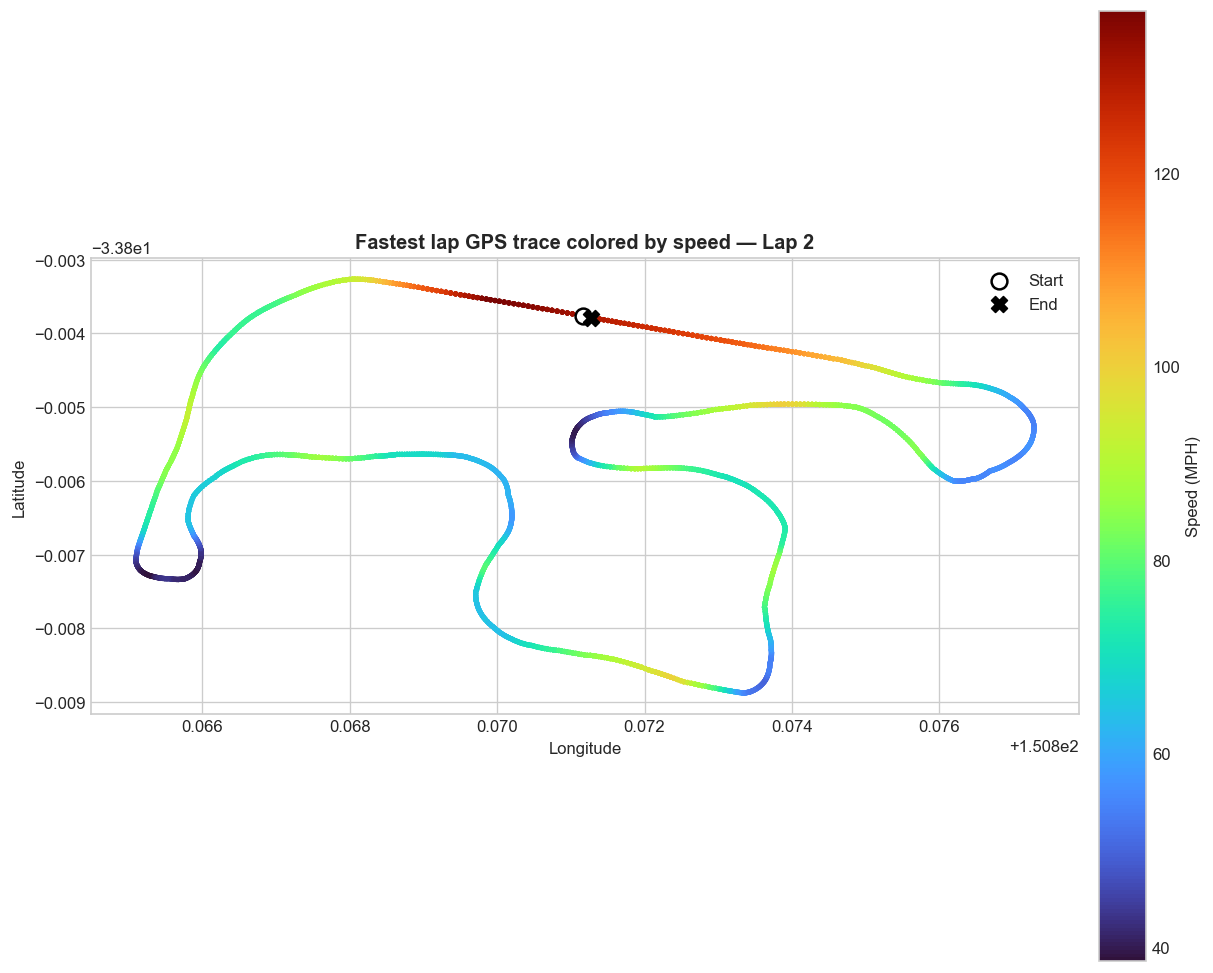

In [9]:
valid_gps = fastest.dropna(subset=["Longitude (decimal)", "Latitude (decimal)", "Speed (MPH)"])
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
track = ax.scatter(
    valid_gps["Longitude (decimal)"], valid_gps["Latitude (decimal)"],
    c=valid_gps["Speed (MPH)"], cmap="turbo", s=10, linewidths=0,
)
ax.scatter(
    valid_gps["Longitude (decimal)"].iloc[0], valid_gps["Latitude (decimal)"].iloc[0],
    marker="o", s=90, facecolor="white", edgecolor="black", linewidth=1.5, label="Start", zorder=3,
)
ax.scatter(
    valid_gps["Longitude (decimal)"].iloc[-1], valid_gps["Latitude (decimal)"].iloc[-1],
    marker="X", s=90, color="black", label="End", zorder=3,
)
ax.set(
    title=f"Fastest lap GPS trace colored by speed — Lap {fastest_lap}",
    xlabel="Longitude", ylabel="Latitude", aspect="equal",
)
ax.legend()
colorbar = fig.colorbar(track, ax=ax, pad=0.02)
colorbar.set_label("Speed (MPH)")
plt.show()

## Notes

- Lap 0 is excluded from lap timing because all of its elapsed-time readings are zero.
- The notebook reports each positive lap ID as recorded; it does not infer whether a lap was an out-lap, in-lap, or interrupted lap.
- Sector boundaries use equal fractions of each lap's measured GPS distance; GPS noise and different racing lines can slightly shift equivalent boundaries between laps.
- GPS is plotted directly in decimal degrees without a basemap, so the notebook remains fully offline and reproducible.